In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np 
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

import os

In [3]:
# os.environ["CUDA_VISIBLE_DEVICES"]="0"
# gpus = tf.config.experimental.list_physical_devices('GPU')
# if gpus:
    # try:
        # tf.config.experimental.set_memory_growth(gpus[0], True)
    # except RuntimeError as e:
        # print(e)

In [4]:
# 데이터 로드
data = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


In [5]:
X = data.values[:, :-1]
Y = data.values[:, -1]
print('X shape:', X.shape)
print('Y Shape:', Y.shape)

X shape: (4998, 140)
Y Shape: (4998,)


In [6]:
# 데이터 전처리
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=7, stratify=Y)
print('Train shape:', x_train.shape)
print('Test shape:', x_test.shape)

from collections import Counter
print(Counter(y_train))
print(Counter(y_test))

Train shape: (3998, 140)
Test shape: (1000, 140)
Counter({1.0: 2335, 0.0: 1663})
Counter({1.0: 584, 0.0: 416})


In [7]:
# 스케일링
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
# print('after:', x_train)

In [8]:
# 데이터 타입 변경 np -> tf
x_train = tf.cast(x_train, tf.float32)
x_test = tf.cast(x_test, tf.float32)

y_train = y_train.astype(bool)
y_test = y_test.astype(bool)

2026-03-07 23:27:06.148774: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-07 23:27:06.148828: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-07 23:27:06.148840: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-03-07 23:27:06.148907: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-07 23:27:06.148948: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


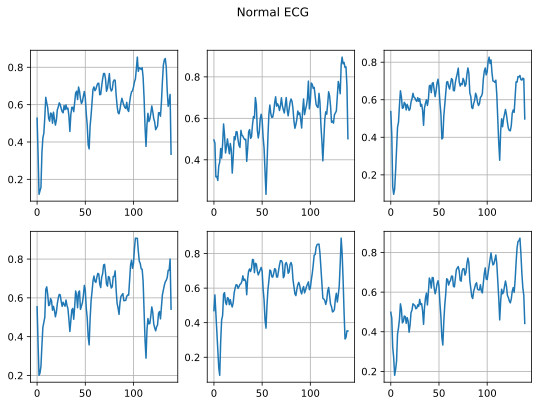

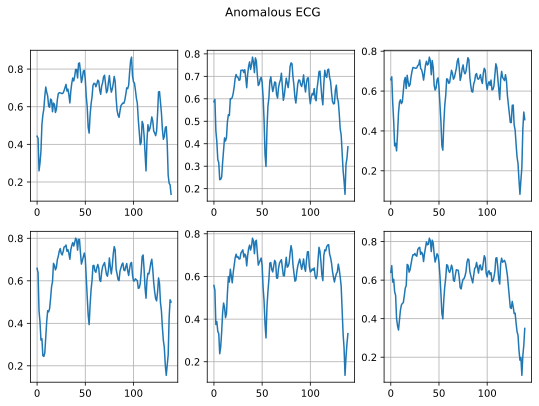

In [9]:
# 데이터 시각화
normal_x_train = x_train[y_train]
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(9,6))
fig.suptitle("Normal ECG")
ax = ax.ravel()
for idx, ax in enumerate(ax):
    ax.grid()
    ax.plot(np.arange(len(normal_x_train[idx])), normal_x_train[idx])
plt.show()

anomalous_x_train = x_train[~y_train]
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(9,6))
fig.suptitle("Anomalous ECG")
ax = ax.ravel()
for idx, ax in enumerate(ax):
    ax.grid()
    ax.plot(np.arange(len(anomalous_x_train[idx])), anomalous_x_train[idx])
plt.show()

**LSTM(RNN) 모델 생성 및 학습**

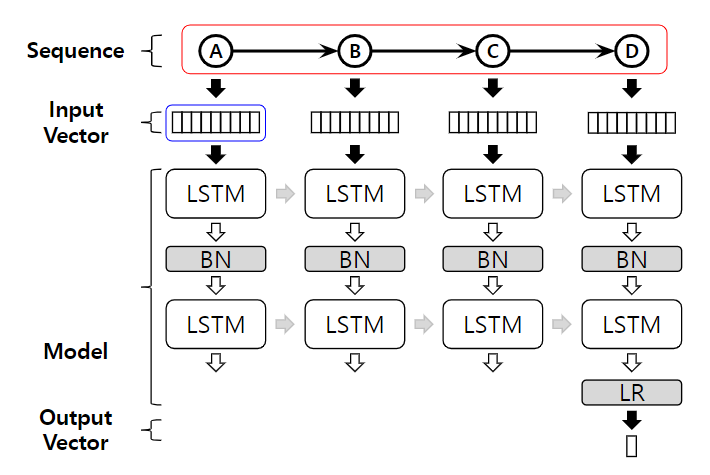

In [10]:
# LSTM(RNN)에 맞는 입력 데이터 차원 변경
x_train_ex = tf.expand_dims(x_train, axis=2)
x_test_ex = tf.expand_dims(x_test, axis=2)

print('원본 차원 정보:', x_train.shape)
print('변경된 차원 정보', x_train_ex.shape)
# (3988, 140, 1) 은 (데이터 개수, 시퀀스 길이, 인풋 벡터 길이)를 의미함.

# 아래 코드로 동일한 효과를 낼 수 있다.
# x_train_ex2 = tf.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_test_ex2 = tf.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
# print('원본 차원 정보:', x_train.shape)
# print('변경된 차원 정보', x_train_ex2.shape)

원본 차원 정보: (3998, 140)
변경된 차원 정보 (3998, 140, 1)


In [11]:
# LSTM(RNN) 모델 생성
model = tf.keras.Sequential([
    layers.Input(shape=(x_train_ex.shape[1], x_train_ex.shape[2])),
    layers.LSTM(100, return_sequences=True),
    layers.Dropout(0.25),
    layers.Bidirectional(layers.LSTM(100)),
    layers.Dropout(0.25),
    layers.Dense(1, activation='sigmoid')
])

# 아래 코드로 동일한 효과를 낼 수 있으며, RNN으로 구현하고 싶다면 layers.RNN을 사용하면 된다.
# model = tf.keras.Sequential()
# model.add(layers.Input(shape=(x_train_ex.shape[1], x_train_ex.shape[2])))
# model.add(layers.LSTM(100, return_sequences=True))
# model.add(layers.Dropout(0.25))
# model.add(layers.Bidirectional(layers.LSTM(100)))
# model.add(layers.Dropout(0.25))
# model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 140, 100)          40800     
                                                                 
 dropout (Dropout)           (None, 140, 100)          0         
                                                                 
 bidirectional (Bidirection  (None, 200)               160800    
 al)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 200)               0         
                                                                 
 dense (Dense)               (None, 1)                 201       
                                                                 
Total params: 201801 (788.29 KB)
Trainable params: 201801 (788.29 KB)
Non-trainable params: 0 (0.00 Byte)
________________

위 요약정보를 통해서 다시 모델을 살펴보자면 아래와 같다.

| 레이어 | 설명 |
|:---|:---|
| **LSTM** | "return_sequences=True"이기 때문에 시퀀스(140)에 대해서 hidden state가 출력되었다. 이때 hidden state의 길이는 100이다. |
| **Dropout** | 25%의 가중치를 랜덤하게 제거한다. 이때 차원정보는 변하지 않는다. |
| **Bidirectional LSTM** | "return_sequences=False"이기 때문에 시퀀스의 마지막 hidden state만 출력된다. 양방향 LSTM을 사용했기 때문에 순방향 hidden state와 역방향 hidden state가 출력되어 200길이의 hidden state가 생성된다. |
| **Dense** | 입력받은 길이 200의 벡터로부터 길이 1의 벡터를 출력한다. 예측 목표가 정상/ 비정상을 판단하는 binary classification의 문제이기 때문이다.|

In [12]:
# 모델 컴파일
model.compile(loss = 'binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# 모델 학습
training_record = model.fit(x_train_ex, y_train,
                            epochs=30,
                            batch_size=128,
                            validation_data=(x_train_ex, y_train),
                            shuffle=True)

Epoch 1/30


2026-03-07 23:27:09.362320: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-07 23:27:09.557618: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


32/32 [==============================] - 11s 167ms/step - loss: 0.4417 - val_loss: 0.0890
Epoch 2/30
32/32 [==============================] - 3s 86ms/step - loss: 0.0857 - val_loss: 0.0674
Epoch 3/30
32/32 [==============================] - 3s 84ms/step - loss: 0.0646 - val_loss: 0.0512
Epoch 4/30
32/32 [==============================] - 3s 91ms/step - loss: 0.0643 - val_loss: 0.0496
Epoch 5/30
32/32 [==============================] - 3s 94ms/step - loss: 0.0492 - val_loss: 0.0521
Epoch 6/30
32/32 [==============================] - 3s 86ms/step - loss: 0.0553 - val_loss: 0.0556
Epoch 7/30
32/32 [==============================] - 3s 85ms/step - loss: 0.0477 - val_loss: 0.0409
Epoch 8/30
32/32 [==============================] - 3s 92ms/step - loss: 0.0443 - val_loss: 0.0445
Epoch 9/30
32/32 [==============================] - 3s 86ms/step - loss: 0.0395 - val_loss: 0.0352
Epoch 10/30
32/32 [==============================] - 3s 87ms/step - loss: 0.0368 - val_loss: 0.0365
Epoch 11/30
32/32 

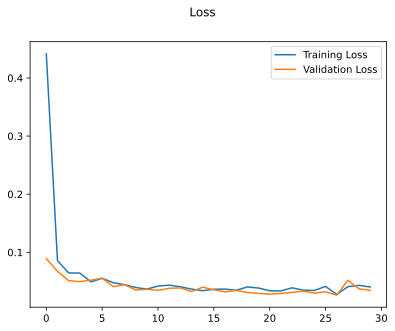

In [13]:
# 학습 곡선 시각화
fig, ax = plt.subplots()
plt.plot(training_record.history["loss"], label="Training Loss")
plt.plot(training_record.history["val_loss"], label="Validation Loss")
plt.legend()
fig.suptitle("Loss")
plt.show()

epoch가 진행됨에 따라 Train 및 Val의 성능을 확인할 수 있다.

두 그래프가 다른 이유: train할 때 batch별로 역전파를 수행하기에 같은 에포크여도 batch마다 사용된 가중치 값이 다르다. 

val은 해당 에포크의 모든 batch에 대한 역전파가 완료된 상태에서 진행되기 때문에 같은 데이터여도 다른 결과값을 가질 수 있다.

In [14]:
# 평가
pred_proba = model.predict(x_test_ex)
# print(pred_proba)

# 현재 pred_proba에 들어있는 값은 True일 확률이지, True/ False로 판단된 값이 아니다.
# 2차원인 pred_proba를 1차원으로 변경해준다. (1000,1)=>(1000)
pred_proba_1d = pred_proba.reshape(-1)

# 임계치 이상이면 True 미만이면 False를 부여한다.
threshold = 0.5
pred = (pred_proba_1d >= threshold)
# print(pred)


32/32 [==============================] - 2s 41ms/step


In [16]:
# 성능 계산하기
accuracy_test_rnn = accuracy_score(y_test, pred)
print(f'Accuracy: {accuracy_test_rnn}')

precision_test_rnn = precision_score(y_test, pred)
print(f'Precision: {round(precision_test_rnn, 3)}')

recall_test_rnn = recall_score(y_test, pred)
print(f'Recall: {round(recall_test_rnn, 3)}')

Accuracy: 0.989
Precision: 0.988
Recall: 0.993
